In [1]:
import xarray as xr
import os
import s3fs
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
import seaborn as sns
import contextily as ctx
import pyproj
from scipy import stats
from scipy.ndimage import uniform_filter1d

In [2]:
load_dotenv()

WASABI_CONFIG = {
    'client_kwargs': {
        'endpoint_url': 'https://s3.wasabisys.com'
    },
    'key': os.getenv('WASABI_ACCESS_KEY'),
    'secret': os.getenv('WASABI_SECRET_KEY')
}

BUCKET = os.getenv('WASABI_DEST_BUCKET')

fs = s3fs.S3FileSystem(**WASABI_CONFIG)

## Carga de los datos

In [3]:
# Apunta a la carpeta que contiene el archivo zarr.json
ruta_zarr_NO2 = f's3://{BUCKET}/GeoVision_Panel/sentinel5p_NO2.zarr'
ruta_zarr_SO2 = f's3://{BUCKET}/GeoVision_Panel/sentinel5p_SO2.zarr'
ruta_zarr_O3 = f's3://{BUCKET}/GeoVision_Panel/sentinel5p_O3.zarr'

In [4]:
# ============================================================
# Cargar datasets en memoria local (solo se ejecuta una vez)
# ============================================================
print("Descargando datasets desde Wasabi...")

ds_no2 = xr.open_zarr(fs.get_mapper(ruta_zarr_NO2)).compute()
ds_so2 = xr.open_zarr(fs.get_mapper(ruta_zarr_SO2)).compute()
ds_o3  = xr.open_zarr(fs.get_mapper(ruta_zarr_O3)).compute()

# Recrear el diccionario con los datos ya en memoria
datasets = {
    'NO2': ds_no2,
    'SO2': ds_so2,
    'O3':  ds_o3
}

print("✅ Datasets en memoria. Ya no se necesita conexión a Wasabi.")
print(f"  NO2: {ds_no2.nbytes / 1e6:.1f} MB")
print(f"  SO2: {ds_so2.nbytes / 1e6:.1f} MB")
print(f"  O3:  {ds_o3.nbytes / 1e6:.1f} MB")

Descargando datasets desde Wasabi...
✅ Datasets en memoria. Ya no se necesita conexión a Wasabi.
  NO2: 1.3 MB
  SO2: 0.9 MB
  O3:  1.3 MB


## Exploración incial

In [5]:
print("--- Dataset NO2 ---")

print(ds_no2)
print(f"Chunks: {ds_no2.chunks}")

--- Dataset NO2 ---
<xarray.Dataset> Size: 1MB
Dimensions:               (time: 1808, lat: 10, lon: 8)
Coordinates:
  * time                  (time) datetime64[ns] 14kB 2020-01-01T18:09:20 ... ...
    cf_mean               (time) float32 7kB 0.514 0.2379 ... 0.5368 0.2826
    cf_p25                (time) float32 7kB 0.1528 0.06602 ... 0.3956 0.09851
    cf_p75                (time) float32 7kB 0.8783 0.4168 ... 0.6933 0.4697
    orbit_id              (time) <U19 137kB '2020-01-01_18-09-20' ... '2024-1...
    valid_pixel_fraction  (time) float32 7kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
  * lat                   (lat) float64 80B 3.741 3.679 3.616 ... 3.238 3.176
  * lon                   (lon) float64 64B -76.75 -76.68 ... -76.37 -76.31
    spatial_ref           int64 8B 0
Data variables:
    NO2                   (time, lat, lon) float32 579kB nan nan ... nan
    NO2_cloud_fraction    (time, lat, lon) float32 579kB 0.8082 ... 0.4824
Chunks: Frozen({})


In [6]:
print("--- Dataset SO2 ---")

print(ds_so2)
print(f"Chunks: {ds_so2.chunks}")

--- Dataset SO2 ---
<xarray.Dataset> Size: 930kB
Dimensions:               (time: 1256, lat: 10, lon: 8)
Coordinates:
  * time                  (time) datetime64[ns] 10kB 2020-01-01T18:09:20 ... ...
    cf_mean               (time) float32 5kB 0.1046 0.09336 ... 0.2267 0.08803
    cf_p25                (time) float32 5kB 0.004666 0.006707 ... 0.2256 0.0152
    cf_p75                (time) float32 5kB 0.1844 0.1543 ... 0.2529 0.1391
    orbit_id              (time) <U19 95kB '2020-01-01_18-09-20' ... '2024-12...
    valid_pixel_fraction  (time) float32 5kB 0.425 0.7625 0.9375 ... 0.05 0.575
  * lat                   (lat) float64 80B 3.741 3.679 3.616 ... 3.238 3.176
  * lon                   (lon) float64 64B -76.75 -76.68 ... -76.37 -76.31
    spatial_ref           int64 8B 0
Data variables:
    SO2                   (time, lat, lon) float32 402kB nan nan ... 3.2e-05 nan
    SO2_cloud_fraction    (time, lat, lon) float32 402kB nan nan ... 0.1437 nan
Chunks: Frozen({})


In [7]:
print("--- Dataset O3 ---")

print(ds_o3)
print(f"Chunks: {ds_o3.chunks}")

--- Dataset O3 ---
<xarray.Dataset> Size: 1MB
Dimensions:               (time: 1816, lat: 10, lon: 8)
Coordinates:
  * time                  (time) datetime64[ns] 15kB 2020-01-01T18:09:20 ... ...
    cf_mean               (time) float32 7kB 0.5941 0.2842 ... 0.877 0.4468
    cf_p25                (time) float32 7kB 0.2088 0.03855 ... 0.7955 0.07085
    cf_p75                (time) float32 7kB 0.9518 0.5134 ... 0.9967 0.8694
    orbit_id              (time) <U19 138kB '2020-01-01_18-09-20' ... '2024-1...
    valid_pixel_fraction  (time) float32 7kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
  * lat                   (lat) float64 80B 3.741 3.679 3.616 ... 3.238 3.176
  * lon                   (lon) float64 64B -76.75 -76.68 ... -76.37 -76.31
    spatial_ref           int64 8B 0
Data variables:
    O3                    (time, lat, lon) float32 581kB 0.1037 ... 0.1136
    O3_cloud_fraction     (time, lat, lon) float32 581kB 0.9478 ... 0.8002
Chunks: Frozen({})


In [8]:
def analizar_integridad(ds, variable):
    # .notnull() devuelve True donde hay datos y False donde hay NaN
    # .any(dim=['lat', 'lon']) verifica si en cada día hay AL MENOS un píxel válido en todo el mapa
    dias_con_datos = ds[variable].notnull().any(dim=['lat', 'lon']).sum().compute()
    total_dias = ds.sizes['time']
    
    print(f"--- Análisis para {variable} ---")
    print(f"Total días en dataset: {total_dias}")
    print(f"Días con datos válidos: {dias_con_datos.values}")
    print(f"Días faltantes: {total_dias - dias_con_datos.values}")

# Ejecutar para cada contaminante
for var, ds in datasets.items():
    analizar_integridad(ds, var)

--- Análisis para NO2 ---
Total días en dataset: 1808
Días con datos válidos: 1311
Días faltantes: 497
--- Análisis para SO2 ---
Total días en dataset: 1256
Días con datos válidos: 1176
Días faltantes: 80
--- Análisis para O3 ---
Total días en dataset: 1816
Días con datos válidos: 1704
Días faltantes: 112


In [9]:
print("--- ELIMINACIÓN DE IMÁGENES SIN PÍXELES VÁLIDOS ---")

# ── Filtrar cada contaminante en su propia variable ──────────────────────────
for name, ds in datasets.items():
    var_name   = name
    total_imgs = ds.sizes['time']

    # Máscara temporal: True = timestamp con AL MENOS un píxel válido
    mask_valida = ds[var_name].notnull().any(dim=['lat', 'lon']).compute()

    n_validas = mask_valida.sum().item()
    n_vacias  = total_imgs - n_validas

    print(f"\n==== {name} ====")
    print(f"  • Imágenes originales        : {total_imgs}")
    print(f"  • Imágenes vacías eliminadas : {n_vacias}  ({n_vacias/total_imgs*100:.2f}%)")
    print(f"  • Imágenes conservadas       : {n_validas} ({n_validas/total_imgs*100:.2f}%)")

    if name == 'NO2':
        ds_no2 = ds.sel(time=mask_valida.values)
        print(f"  • Guardado en: ds_no2  →  {ds_no2.sizes}")

    elif name == 'SO2':
        ds_so2 = ds.sel(time=mask_valida.values)
        print(f"  • Guardado en: ds_so2  →  {ds_so2.sizes}")

    elif name == 'O3':
        ds_o3 = ds.sel(time=mask_valida.values)
        print(f"  • Guardado en: ds_o3  →  {ds_o3.sizes}")

# ── Actualizar el diccionario datasets para el resto del notebook ─────────────
datasets = {
    'NO2': ds_no2,
    'SO2': ds_so2,
    'O3' : ds_o3,
}

print("\n--- RESUMEN FINAL ---")
for name, ds in datasets.items():
    print(f"  • {name}: {ds.sizes['time']} imágenes  |  "
          f"{ds.time.values[0]} → {ds.time.values[-1]}")

--- ELIMINACIÓN DE IMÁGENES SIN PÍXELES VÁLIDOS ---

==== NO2 ====
  • Imágenes originales        : 1808
  • Imágenes vacías eliminadas : 497  (27.49%)
  • Imágenes conservadas       : 1311 (72.51%)
  • Guardado en: ds_no2  →  Frozen({'time': 1311, 'lat': 10, 'lon': 8})

==== SO2 ====
  • Imágenes originales        : 1256
  • Imágenes vacías eliminadas : 80  (6.37%)
  • Imágenes conservadas       : 1176 (93.63%)
  • Guardado en: ds_so2  →  Frozen({'time': 1176, 'lat': 10, 'lon': 8})

==== O3 ====
  • Imágenes originales        : 1816
  • Imágenes vacías eliminadas : 112  (6.17%)
  • Imágenes conservadas       : 1704 (93.83%)
  • Guardado en: ds_o3  →  Frozen({'time': 1704, 'lat': 10, 'lon': 8})

--- RESUMEN FINAL ---
  • NO2: 1311 imágenes  |  2020-01-01T18:09:20.000000000 → 2024-12-31T17:31:33.000000000
  • SO2: 1176 imágenes  |  2020-01-01T18:09:20.000000000 → 2024-12-31T17:31:33.000000000
  • O3: 1704 imágenes  |  2020-01-01T18:09:20.000000000 → 2024-12-31T17:31:33.000000000


## Rangos de valor por contaminante

In [10]:
# Configuración de estilo
sns.set_theme(style="white")

print("--- 1. RANGOS DE VALORES EN LOS CONTAMINANTES ---")

for name, ds in datasets.items():
    var_name = name
    valores = ds[var_name].values.flatten()
    valores_validos = valores[~np.isnan(valores)]
    
    print(f"\n==== Estadísticas para {name} ====")
    if len(valores_validos) == 0:
        print("❌ ¡Alerta! El dataset solo contiene valores nulos.")
        continue
        
    print(f"• Valor Mínimo: {valores_validos.min():.6e}")
    print(f"• Percentil 25: {np.percentile(valores_validos, 25):.6e}")
    print(f"• Mediana (P50): {np.median(valores_validos):.6e}")
    print(f"• Percentil 75: {np.percentile(valores_validos, 75):.6e}")
    print(f"• Valor Máximo: {valores_validos.max():.6e}")
    print(f"• Desviación Estándar: {valores_validos.std():.6e}")

--- 1. RANGOS DE VALORES EN LOS CONTAMINANTES ---

==== Estadísticas para NO2 ====
• Valor Mínimo: -2.791579e-05
• Percentil 25: 1.337323e-05
• Mediana (P50): 2.011293e-05
• Percentil 75: 2.800729e-05
• Valor Máximo: 1.765384e-04
• Desviación Estándar: 1.490259e-05

==== Estadísticas para SO2 ====
• Valor Mínimo: -9.974295e-04
• Percentil 25: -9.264481e-05
• Mediana (P50): 4.858007e-05
• Percentil 75: 2.008248e-04
• Valor Máximo: 1.333219e-02
• Desviación Estándar: 3.197463e-04

==== Estadísticas para O3 ====
• Valor Mínimo: 9.936602e-02
• Percentil 25: 1.120681e-01
• Mediana (P50): 1.159220e-01
• Percentil 75: 1.200969e-01
• Valor Máximo: 1.472987e-01
• Desviación Estándar: 5.699233e-03


## Analisis de distribución de pixeles nulos

--- ANALISIS DE CALIDAD Y PIXELES NULL/NaN CON COORDENADAS REALES ---

==== Procesando Dataset: NO2 ====
• Total de píxeles analizados: 104,880
• Píxeles Nulos (NaN): 60,575 (57.76%)
• Píxeles Válidos: 44,305 (42.24%)


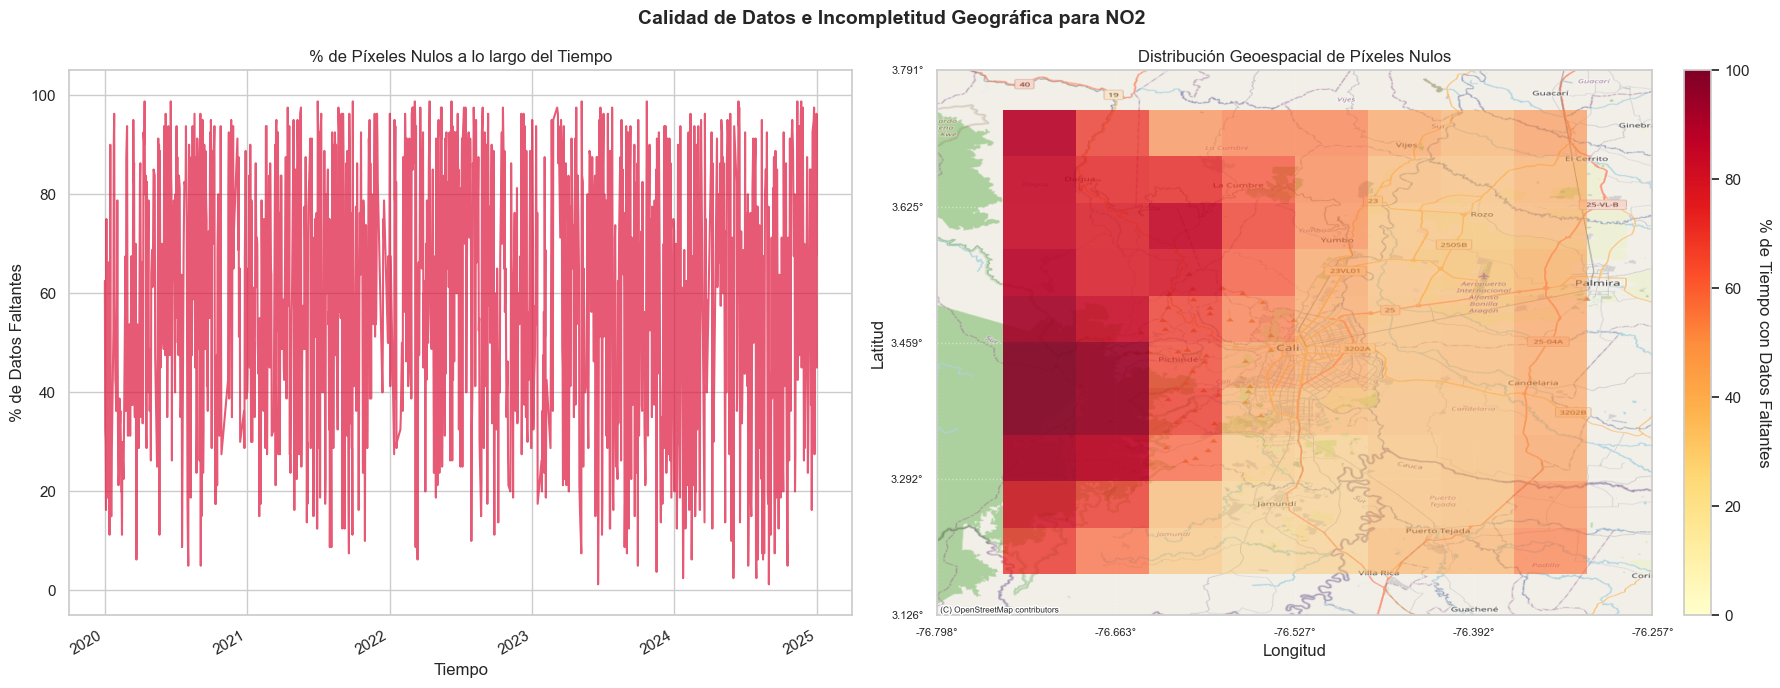


==== Procesando Dataset: SO2 ====
• Total de píxeles analizados: 94,080
• Píxeles Nulos (NaN): 53,629 (57.00%)
• Píxeles Válidos: 40,451 (43.00%)


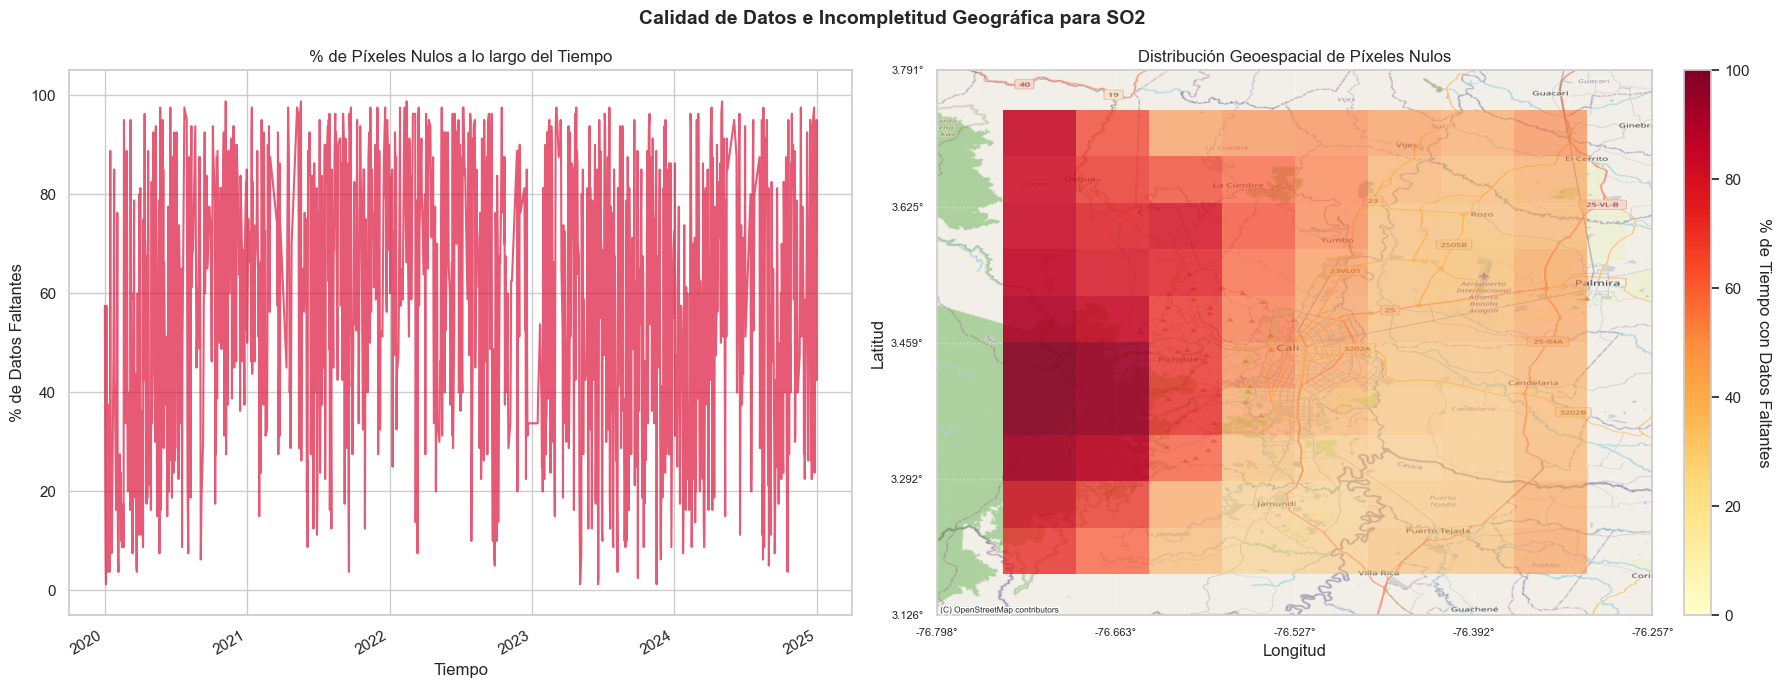


==== Procesando Dataset: O3 ====
• Total de píxeles analizados: 136,320
• Píxeles Nulos (NaN): 4,404 (3.23%)
• Píxeles Válidos: 131,916 (96.77%)


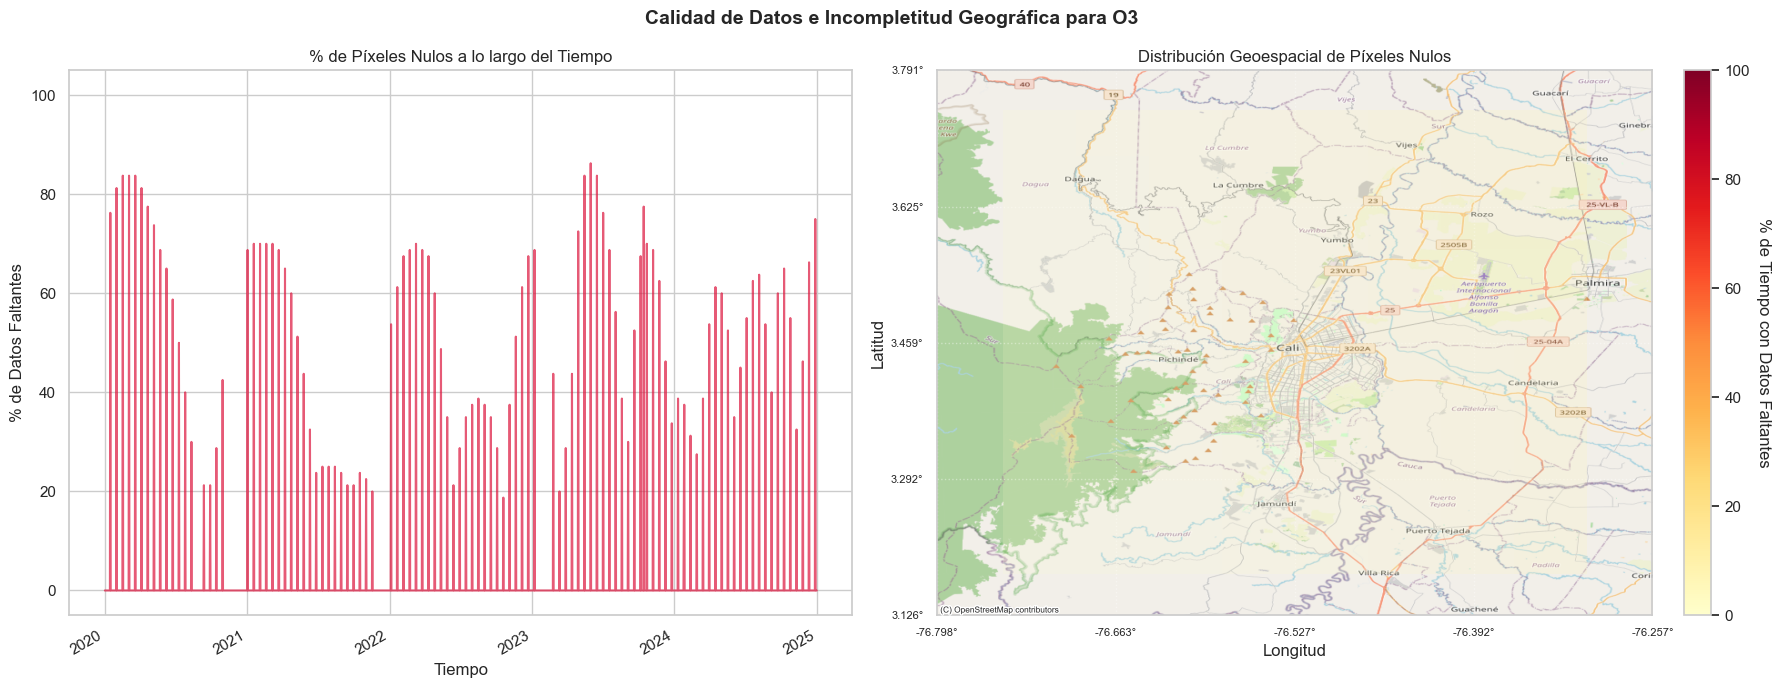

In [11]:
# Configuración estética básica
sns.set_theme(style="whitegrid")

print("--- ANALISIS DE CALIDAD Y PIXELES NULL/NaN CON COORDENADAS REALES ---")

for name, ds in datasets.items():
    print(f"\n==== Procesando Dataset: {name} ====")
    
    # 1. Identificar la variable principal del contaminante dinámicamente
    var_name = name 
    data_array = ds[var_name]
    
    # Extracción de los vectores de coordenadas geográficas para el mapa
    lats = ds.lat.values
    lons = ds.lon.values
    
    # Total de píxeles teóricos en el cubo (Time x Lat x Lon)
    total_pixels = data_array.size
    
    # Calcular nulos totales
    null_pixels = data_array.isnull().sum().compute().item()
    pct_null_total = (null_pixels / total_pixels) * 100
    
    print(f"• Total de píxeles analizados: {total_pixels:,}")
    print(f"• Píxeles Nulos (NaN): {null_pixels:,} ({pct_null_total:.2f}%)")
    print(f"• Píxeles Válidos: {total_pixels - null_pixels:,} ({100 - pct_null_total:.2f}%)")
    
    # --- 2. DISTRIBUCIÓN TEMPORAL DE NULOS ---
    null_by_time = data_array.isnull().mean(dim=['lat', 'lon']).compute().to_pandas() * 100
    
    # --- 3. DISTRIBUCION ESPACIAL DE NULOS ---
    null_by_space = data_array.isnull().mean(dim='time').compute() * 100
    
    # --- 4. GRAFICACIÓN MAPA + LÍNEA TEMPORAL ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f"Calidad de Datos e Incompletitud Geográfica para {name}", fontsize=14, fontweight='bold')
    
    # ── [Gráfico 1] Distribución Temporal ────────────────────────────────────
    null_by_time.plot(ax=axes[0], color='crimson', alpha=0.7, lw=1.5)
    axes[0].set_title("% de Píxeles Nulos a lo largo del Tiempo")
    axes[0].set_ylabel("% de Datos Faltantes")
    axes[0].set_xlabel("Tiempo")
    axes[0].set_ylim(-5, 105)
    
    # ── [Gráfico 2] Mapa de Calor Espacial con mapa base ────────────────────
    ax_map = axes[1]

    # --- Conversión de coordenadas WGS84 → Web Mercator (EPSG:3857) ---
    # contextily trabaja en Web Mercator, así que debemos proyectar el extent
    import pyproj
    transformer = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

    # Esquinas del dominio en Web Mercator
    lon_min, lon_max = lons.min(), lons.max()
    lat_min, lat_max = lats.min(), lats.max()

    # Añadir un pequeño buffer para que el tile no quede exactamente en el borde
    buffer_deg = 0.05
    west, south = transformer.transform(lon_min - buffer_deg, lat_min - buffer_deg)
    east, north = transformer.transform(lon_max + buffer_deg, lat_max + buffer_deg)

    # Proyectar las esquinas del heatmap (sin buffer)
    west_data, south_data = transformer.transform(lon_min, lat_min)
    east_data, north_data = transformer.transform(lon_max, lat_max)

    # --- Preparar la imagen del heatmap con transparencia (alpha) ---
    cmap_heat = plt.cm.YlOrRd
    norm = Normalize(vmin=0, vmax=100)

    # null_by_space tiene dims (lat, lon). 
    # Con origin='upper', la fila 0 = lat más alta → ya está en orden correcto.
    heat_values = null_by_space.values  # shape (lat, lon)

    # Convertir a RGBA para poder controlar alpha por píxel
    rgba_heat = cmap_heat(norm(heat_values))           # (lat, lon, 4)
    
    # Ajustar alpha: pixels con 0% nulos se hacen más transparentes
    # para que el mapa base sea visible; pixels con más nulos, más opacos
    alpha_matrix = np.clip(norm(heat_values) * 0.85 + 0.15, 0.15, 0.90)
    rgba_heat[..., 3] = alpha_matrix

    # --- Dibujar el mapa base con contextily ---
    ax_map.set_xlim(west, east)
    ax_map.set_ylim(south, north)

    # Agregar tiles del mapa base (OpenStreetMap por defecto)
    ctx.add_basemap(
        ax_map,
        crs="EPSG:3857",
        source=ctx.providers.OpenStreetMap.Mapnik,
        zoom='auto',
        attribution_size=6
    )

    # --- Superponer el heatmap sobre el mapa base ---
    ax_map.imshow(
        rgba_heat,
        extent=[west_data, east_data, south_data, north_data],  # en Web Mercator
        origin='upper',   # lat descendente (como vienen de Sentinel)
        aspect='auto',
        zorder=2          # encima del mapa base
    )

    # --- Ejes: mostrar en grados (WGS84) aunque internamente estemos en Mercator ---
    # Convertimos ticks de Mercator → grados para que el usuario lea coordenadas
    x_ticks_merc = np.linspace(west, east, 5)
    y_ticks_merc = np.linspace(south, north, 5)

    inv_transformer = pyproj.Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)
    x_ticks_deg = [inv_transformer.transform(x, south)[0] for x in x_ticks_merc]
    y_ticks_deg = [inv_transformer.transform(west, y)[1] for y in y_ticks_merc]

    ax_map.set_xticks(x_ticks_merc)
    ax_map.set_xticklabels([f"{d:.3f}°" for d in x_ticks_deg], fontsize=8)
    ax_map.set_yticks(y_ticks_merc)
    ax_map.set_yticklabels([f"{d:.3f}°" for d in y_ticks_deg], fontsize=8)

    ax_map.set_title("Distribución Geoespacial de Píxeles Nulos")
    ax_map.set_xlabel("Longitud")
    ax_map.set_ylabel("Latitud")
    ax_map.grid(True, linestyle=':', alpha=0.4, color='white', zorder=3)

    # --- Barra de color (referenciada al colormap, no a imshow) ---
    sm = ScalarMappable(cmap=cmap_heat, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax_map, fraction=0.046, pad=0.04)
    cbar.set_label('% de Tiempo con Datos Faltantes', rotation=270, labelpad=15)
    
    plt.tight_layout()
    plt.show()

--- DIAGNÓSTICO DE IMÁGENES CRÍTICAS — GRID COMPLETO ---
  • NO2: umbral máximo de nulos permitido = 85%
  • SO2: umbral máximo de nulos permitido = 85%
  • O3: umbral máximo de nulos permitido = 60%

==== Contaminante: NO2 (umbral=85%) — GLOBAL ====
  • Total de imágenes               : 1311
  • Imágenes válidas  (≤ 85% nulos): 1042 (79.48%)
  • Imágenes críticas (> 85% nulos): 269 (20.52%)

==== Contaminante: SO2 (umbral=85%) — GLOBAL ====
  • Total de imágenes               : 1176
  • Imágenes válidas  (≤ 85% nulos): 940 (79.93%)
  • Imágenes críticas (> 85% nulos): 236 (20.07%)

==== Contaminante: O3 (umbral=60%) — GLOBAL ====
  • Total de imágenes               : 1704
  • Imágenes válidas  (≤ 60% nulos): 1661 (97.48%)
  • Imágenes críticas (> 60% nulos): 43 (2.52%)


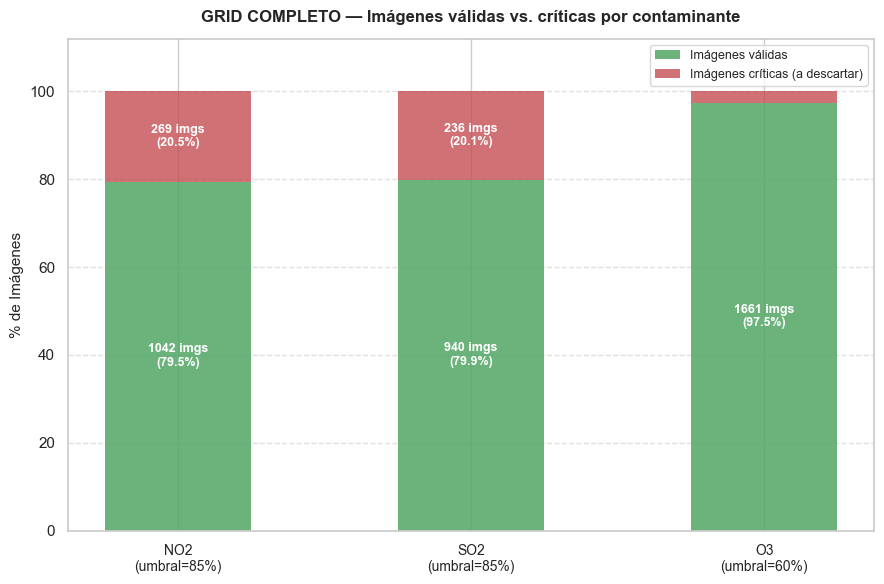

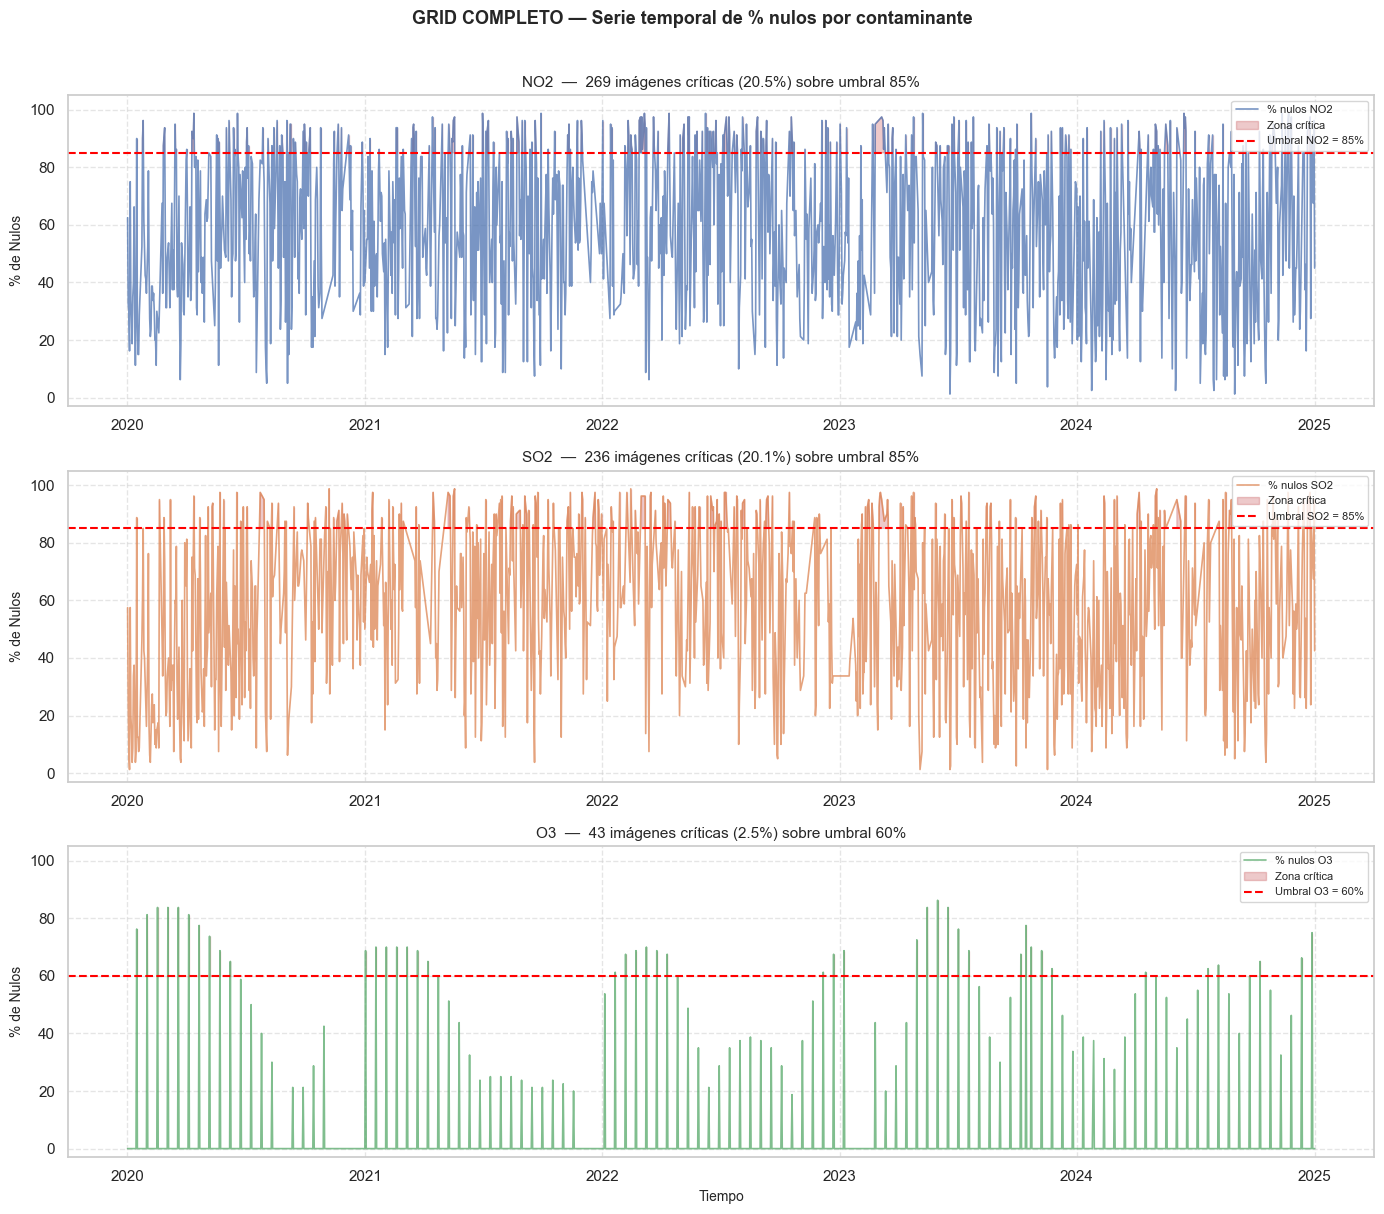

In [12]:
# ─── Umbrales diferenciados por contaminante ────────────────────────────────
UMBRALES_POR_CONTAMINANTE = {
    'NO2': 85.0,
    'SO2': 85.0,
    'O3' : 60.0,
}

print("--- DIAGNÓSTICO DE IMÁGENES CRÍTICAS — GRID COMPLETO ---")
for name, umbral in UMBRALES_POR_CONTAMINANTE.items():
    print(f"  • {name}: umbral máximo de nulos permitido = {umbral:.0f}%")

resumen_global = {}

for name, ds in datasets.items():
    umbral     = UMBRALES_POR_CONTAMINANTE[name]
    data_array = ds[name]

    pct_null_per_time = data_array.isnull().mean(dim=['lat', 'lon']).compute() * 100

    total_imagenes    = len(ds.time)
    imagenes_criticas = (pct_null_per_time > umbral).sum().item()
    imagenes_validas  = total_imagenes - imagenes_criticas
    pct_critico       = (imagenes_criticas / total_imagenes) * 100
    pct_valido        = 100 - pct_critico

    resumen_global[name] = {
        'umbral'            : umbral,
        'total'             : total_imagenes,
        'n_criticas'        : imagenes_criticas,
        'n_validas'         : imagenes_validas,
        'pct_critico'       : pct_critico,
        'pct_valido'        : pct_valido,
        'pct_null_per_time' : pct_null_per_time,
    }

    print(f"\n==== Contaminante: {name} (umbral={umbral:.0f}%) — GLOBAL ====")
    print(f"  • Total de imágenes               : {total_imagenes}")
    print(f"  • Imágenes válidas  (≤ {umbral:.0f}% nulos): {imagenes_validas} ({pct_valido:.2f}%)")
    print(f"  • Imágenes críticas (> {umbral:.0f}% nulos): {imagenes_criticas} ({pct_critico:.2f}%)")

# ── Figura 1: Barras apiladas ─────────────────────────────────────────────
nombres   = list(resumen_global.keys())
pct_val   = [resumen_global[n]['pct_valido']  for n in nombres]
pct_crit  = [resumen_global[n]['pct_critico'] for n in nombres]
n_val     = [resumen_global[n]['n_validas']   for n in nombres]
n_crit    = [resumen_global[n]['n_criticas']  for n in nombres]
umbrales  = [resumen_global[n]['umbral']      for n in nombres]
x         = np.arange(len(nombres))
bar_width = 0.5

fig, ax = plt.subplots(figsize=(9, 6))
bars_v = ax.bar(x, pct_val,  bar_width, label='Imágenes válidas',
                color='#55A868', alpha=0.87, edgecolor='none')
bars_c = ax.bar(x, pct_crit, bar_width, label='Imágenes críticas (a descartar)',
                bottom=pct_val, color='#C44E52', alpha=0.80, edgecolor='none')

for i, (bv, bc) in enumerate(zip(bars_v, bars_c)):
    if pct_val[i] > 6:
        ax.text(bv.get_x() + bv.get_width() / 2, pct_val[i] / 2,
                f"{n_val[i]} imgs\n({pct_val[i]:.1f}%)",
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    if pct_crit[i] > 6:
        ax.text(bc.get_x() + bc.get_width() / 2,
                pct_val[i] + pct_crit[i] / 2,
                f"{n_crit[i]} imgs\n({pct_crit[i]:.1f}%)",
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{n}\n(umbral={umbrales[i]:.0f}%)" for i, n in enumerate(nombres)], fontsize=10)
ax.set_title("GRID COMPLETO — Imágenes válidas vs. críticas por contaminante",
             fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel("% de Imágenes", fontsize=11)
ax.set_ylim(0, 112)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

# ── Figura 2: Series temporales ───────────────────────────────────────────
colores = {'NO2': '#4C72B0', 'SO2': '#DD8452', 'O3': '#55A868'}

fig2, axes2 = plt.subplots(len(nombres), 1, figsize=(14, 4 * len(nombres)), sharex=False)
fig2.suptitle("GRID COMPLETO — Serie temporal de % nulos por contaminante",
              fontsize=13, fontweight='bold', y=1.01)

for ax, name in zip(axes2, nombres):
    datos  = resumen_global[name]
    umbral = datos['umbral']
    serie  = datos['pct_null_per_time'].to_pandas()

    ax.plot(serie.index, serie.values, lw=1.2,
            color=colores[name], alpha=0.75, label=f'% nulos {name}')
    ax.fill_between(serie.index, umbral, serie.values,
                    where=(serie.values > umbral),
                    color='#C44E52', alpha=0.30, label='Zona crítica')
    ax.axhline(umbral, color='red', lw=1.5, linestyle='--',
               label=f'Umbral {name} = {umbral:.0f}%')
    ax.set_title(f"{name}  —  {datos['n_criticas']} imágenes críticas "
                 f"({datos['pct_critico']:.1f}%) sobre umbral {umbral:.0f}%", fontsize=11)
    ax.set_ylabel("% de Nulos", fontsize=10)
    ax.set_ylim(-3, 105)
    ax.grid(linestyle='--', alpha=0.5)
    ax.legend(fontsize=8, loc='upper right')

axes2[-1].set_xlabel("Tiempo", fontsize=10)
plt.tight_layout()
plt.show()

In [13]:
print("--- FILTRADO POR UMBRAL DE NULOS POR CONTAMINANTE ---")

for name, ds in datasets.items():
    umbral     = UMBRALES_POR_CONTAMINANTE[name]
    total_imgs = ds.sizes['time']

    # % de nulos por imagen
    pct_null_per_time = ds[name].isnull().mean(dim=['lat', 'lon']).compute() * 100

    # Máscara: True = imagen que PASA el filtro (nulos <= umbral)
    mask_valida = pct_null_per_time <= umbral

    n_validas = mask_valida.sum().item()
    n_descart = total_imgs - n_validas

    print(f"\n==== {name} (umbral={umbral:.0f}%) ====")
    print(f"  • Imágenes originales  : {total_imgs}")
    print(f"  • Imágenes descartadas : {n_descart}  ({n_descart/total_imgs*100:.2f}%)")
    print(f"  • Imágenes conservadas : {n_validas} ({n_validas/total_imgs*100:.2f}%)")

    if name == 'NO2':
        ds_no2 = ds.sel(time=mask_valida.values)
        print(f"  • Guardado en: ds_no2  →  {ds_no2.sizes}")

    elif name == 'SO2':
        ds_so2 = ds.sel(time=mask_valida.values)
        print(f"  • Guardado en: ds_so2  →  {ds_so2.sizes}")

    elif name == 'O3':
        ds_o3 = ds.sel(time=mask_valida.values)
        print(f"  • Guardado en: ds_o3  →  {ds_o3.sizes}")

# ── Actualizar diccionario ────────────────────────────────────────────────────
datasets = {
    'NO2': ds_no2,
    'SO2': ds_so2,
    'O3' : ds_o3,
}

print("\n--- RESUMEN FINAL ---")
for name, ds in datasets.items():
    print(f"  • {name}: {ds.sizes['time']} imágenes  |  "
          f"{ds.time.values[0]} → {ds.time.values[-1]}")

--- FILTRADO POR UMBRAL DE NULOS POR CONTAMINANTE ---

==== NO2 (umbral=85%) ====
  • Imágenes originales  : 1311
  • Imágenes descartadas : 269  (20.52%)
  • Imágenes conservadas : 1042 (79.48%)
  • Guardado en: ds_no2  →  Frozen({'time': 1042, 'lat': 10, 'lon': 8})

==== SO2 (umbral=85%) ====
  • Imágenes originales  : 1176
  • Imágenes descartadas : 236  (20.07%)
  • Imágenes conservadas : 940 (79.93%)
  • Guardado en: ds_so2  →  Frozen({'time': 940, 'lat': 10, 'lon': 8})

==== O3 (umbral=60%) ====
  • Imágenes originales  : 1704
  • Imágenes descartadas : 43  (2.52%)
  • Imágenes conservadas : 1661 (97.48%)
  • Guardado en: ds_o3  →  Frozen({'time': 1661, 'lat': 10, 'lon': 8})

--- RESUMEN FINAL ---
  • NO2: 1042 imágenes  |  2020-01-01T18:09:20.000000000 → 2024-12-31T17:31:33.000000000
  • SO2: 940 imágenes  |  2020-01-01T18:09:20.000000000 → 2024-12-31T17:31:33.000000000
  • O3: 1661 imágenes  |  2020-01-01T18:09:20.000000000 → 2024-12-31T17:31:33.000000000


## Imputación de nulos

In [14]:
from scipy.ndimage import label, sum as ndi_sum
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import generic_filter

# ── Funciones de imputación ──────────────────────────────────────────────────

def clasificar_huecos(mask_2d):
    etiquetas, num_huecos = label(mask_2d)
    mapa_estrategia = np.zeros_like(mask_2d, dtype=np.int8)
    if num_huecos == 0:
        return mapa_estrategia, []
    tamaños = ndi_sum(mask_2d, etiquetas, range(1, num_huecos + 1))
    for idx, tamaño in enumerate(tamaños, start=1):
        px = etiquetas == idx
        if tamaño < 9:
            mapa_estrategia[px] = 1      # pequeño → interpolación lineal
        elif tamaño <= 25:
            mapa_estrategia[px] = 2      # mediano → promedio de bordes
        else:
            mapa_estrategia[px] = 3      # grande  → climatología
    return mapa_estrategia, tamaños

def imputar_lineal(imagen):
    img = imagen.copy()
    lats_idx = np.arange(img.shape[0])
    lons_idx = np.arange(img.shape[1])
    mask_validos = ~np.isnan(img)
    if mask_validos.sum() < 4:
        return img
    interpolador = RegularGridInterpolator(
        (lats_idx, lons_idx),
        np.where(mask_validos, img, 0.0),
        method='linear', bounds_error=False, fill_value=np.nan
    )
    coords_nan = np.argwhere(np.isnan(img))
    if len(coords_nan) > 0:
        img[np.isnan(img)] = interpolador(coords_nan)
    return img

def imputar_promedio_bordes(imagen, mapa_estrategia, estado=2):
    img = imagen.copy()
    mask_hueco = mapa_estrategia == estado
    def mean_validos(ventana):
        centro = ventana[4]
        if not np.isnan(centro):
            return centro
        vecinos = ventana[~np.isnan(ventana)]
        return vecinos.mean() if len(vecinos) > 0 else np.nan
    img_filtrada = generic_filter(img, mean_validos, size=3, mode='nearest')
    img[mask_hueco] = img_filtrada[mask_hueco]
    return img

def imputar_climatologia(imagen, clim_mes_2d, mapa_estrategia, estado=3):
    img = imagen.copy()
    mask_grande = mapa_estrategia == estado
    img[mask_grande] = clim_mes_2d[mask_grande]
    return img

[NO2] Total de huecos detectados: 2168
  Pequeño (<9px):      2,630 px  (6.5%)
  Mediano (9-25px):      6,429 px  (15.8%)
  Grande (>25px):     31,681 px  (77.8%)

[SO2] Total de huecos detectados: 1790
  Pequeño (<9px):      2,117 px  (5.8%)
  Mediano (9-25px):      5,194 px  (14.3%)
  Grande (>25px):     28,888 px  (79.8%)

[O3] Total de huecos detectados: 64
  Pequeño (<9px):          0 px  (0.0%)
  Mediano (9-25px):        454 px  (23.3%)
  Grande (>25px):      1,494 px  (76.7%)



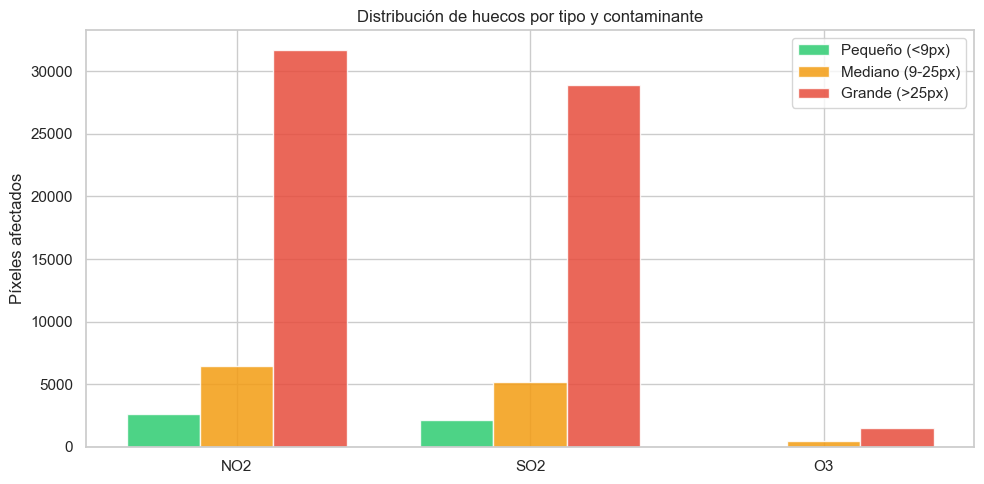

In [15]:
# ============================================================
# BLOQUE 2: Análisis de distribución de huecos por contaminante
# ============================================================
import pandas as pd

ESTADO_LABELS = {1: 'Pequeño (<9px)',  2: 'Mediano (9-25px)', 3: 'Grande (>25px)'}

resumen_huecos = {}

for nombre, ds in datasets.items():
    valores_np = ds[nombre].compute().values   # (time, lat, lon)

    conteos = {1: 0, 2: 0, 3: 0}
    total_huecos = 0

    for t in range(valores_np.shape[0]):
        imagen = valores_np[t]
        mask_nan = np.isnan(imagen)
        if not mask_nan.any():
            continue
        mapa_est, tamaños = clasificar_huecos(mask_nan)
        conteos[1] += int((mapa_est == 1).sum())
        conteos[2] += int((mapa_est == 2).sum())
        conteos[3] += int((mapa_est == 3).sum())
        total_huecos += len(tamaños)

    total_px_huecos = sum(conteos.values())
    resumen_huecos[nombre] = conteos

    print(f"[{nombre}] Total de huecos detectados: {total_huecos}")
    for estado, label_str in ESTADO_LABELS.items():
        px = conteos[estado]
        pct = px / total_px_huecos * 100 if total_px_huecos > 0 else 0
        print(f"  {label_str}: {px:>10,} px  ({pct:.1f}%)")
    print()

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(10, 5))
x      = np.arange(len(datasets))
ancho  = 0.25
colors = ['#2ecc71', '#f39c12', '#e74c3c']

for i, (estado, label_str, color) in enumerate(zip([1, 2, 3], ESTADO_LABELS.values(), colors)):
    valores_bar = [resumen_huecos[n][estado] for n in datasets]
    ax.bar(x + i * ancho, valores_bar, ancho, label=label_str, color=color, alpha=0.85)

ax.set_xticks(x + ancho)
ax.set_xticklabels(datasets.keys())
ax.set_ylabel('Píxeles afectados')
ax.set_title('Distribución de huecos por tipo y contaminante')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# IMPUTACIÓN 1: NaN por tamaño de hueco
# Entrada : ds_no2, ds_so2, ds_o3 (después del filtrado por umbral de nulos)
# Salida  : intermedios dict con arrays numpy (time, lat, lon) sin NaN
# ============================================================


# ── Construir climatología mensual (solo píxeles con cf < 0.3) ──────────────
climatologia = {}

for nombre, ds in datasets.items():
    cf_px          = ds[f'{nombre}_cloud_fraction']
    valores_buenos = ds[nombre].where(cf_px < 0.3)
    clim = (
        valores_buenos
        .groupby('time.month')
        .mean(dim='time')
    )
    climatologia[nombre] = clim
    print(f"[{nombre}] Climatología mensual construida: {clim.dims} → {clim.shape}")

print("\n✅ Climatología lista. Iniciando imputación de NaN...\n")

# ── Imputación por tamaño de hueco ───────────────────────────────────────────
intermedios = {}

for nombre, ds in datasets.items():
    valores_np = ds[nombre].values              # (time, lat, lon) ya en memoria
    clim       = climatologia[nombre]
    meses      = ds['time.month'].values
    n_time, n_lat, n_lon = valores_np.shape

    resultado = np.empty_like(valores_np)

    for t in range(n_time):
        imagen   = valores_np[t].copy()
        clim_mes = clim.sel(month=int(meses[t])).values
        mask_nan = np.isnan(imagen)

        if not mask_nan.any():
            resultado[t] = imagen
            continue

        mapa_est, _ = clasificar_huecos(mask_nan)

        if (mapa_est == 3).any():
            imagen = imputar_climatologia(imagen, clim_mes, mapa_est, estado=3)
        if (mapa_est == 2).any():
            imagen = imputar_promedio_bordes(imagen, mapa_est, estado=2)
        if (mapa_est == 1).any():
            imagen = imputar_lineal(imagen)

        resultado[t] = imagen

    intermedios[nombre] = resultado

    nan_restantes = np.isnan(resultado).sum()
    print(f"[{nombre}] ✅ Imputación de NaN completa — NaN restantes: {nan_restantes}")

[NO2] Climatología mensual construida: ('month', 'lat', 'lon') → (12, 10, 8)
[SO2] Climatología mensual construida: ('month', 'lat', 'lon') → (12, 10, 8)
[O3] Climatología mensual construida: ('month', 'lat', 'lon') → (12, 10, 8)

✅ Climatología lista. Iniciando imputación de NaN...

[NO2] ✅ Imputación de NaN completa — NaN restantes: 919
[SO2] ✅ Imputación de NaN completa — NaN restantes: 634
[O3] ✅ Imputación de NaN completa — NaN restantes: 178


## Analisis por cloud_fraction

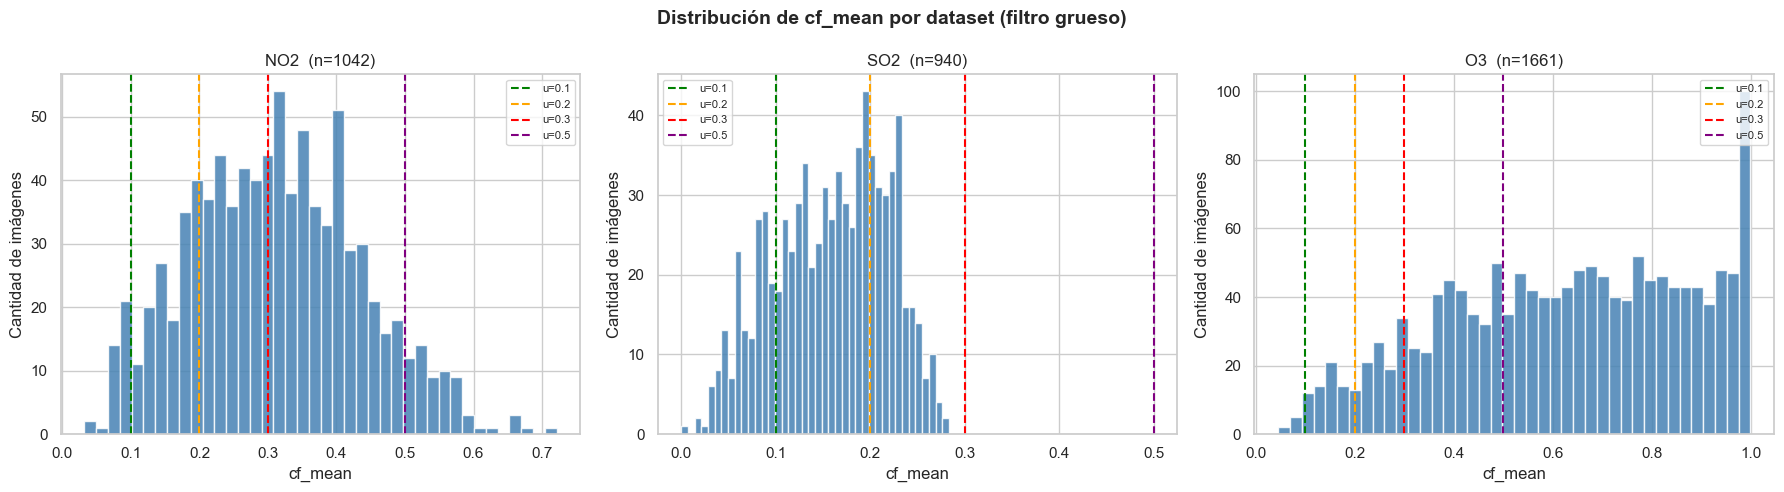


📊 Resumen filtro grueso (cf_mean a nivel de imagen):
Dataset  Umbral  Total imágenes  Válidas  Inválidas  % Válidas
    NO2     0.1            1042       36        834       3.45
    NO2     0.2            1042      180        690      17.27
    NO2     0.3            1042      414        456      39.73
    NO2     0.5            1042      808         62      77.54
    SO2     0.1             940      162        637      17.23
    SO2     0.2             940      569        230      60.53
    SO2     0.3             940      799          0      85.00
    SO2     0.5             940      799          0      85.00
     O3     0.1            1661       13       1437       0.78
     O3     0.2            1661       73       1377       4.39
     O3     0.3            1661      169       1281      10.17
     O3     0.5            1661      476        974      28.66


In [17]:
# ============================================================
# BLOQUE 1: Análisis de cf_mean a nivel de imagen completa
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

UMBRALES = [0.1, 0.2, 0.3, 0.5]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de cf_mean por dataset (filtro grueso)', fontsize=14, fontweight='bold')

resumen_grueso = {}

for ax, (nombre, ds) in zip(axes, datasets.items()):
    cf_mean = ds['cf_mean'].values  # shape: (time,)

    # Estadísticas básicas
    stats = {
        'total_imagenes': len(cf_mean),
        'cf_mean_global': float(np.nanmean(cf_mean)),
        'cf_median':      float(np.nanmedian(cf_mean)),
        'cf_std':         float(np.nanstd(cf_mean)),
    }

    # Imágenes válidas e inválidas por cada umbral
    for u in UMBRALES:
        n_validas   = int(np.sum(cf_mean <= u))
        n_invalidas = int(np.sum(cf_mean >  u))
        pct_validas = n_validas / stats['total_imagenes'] * 100
        stats[f'validas_u{u}']   = n_validas
        stats[f'invalidas_u{u}'] = n_invalidas
        stats[f'pct_validas_u{u}'] = round(pct_validas, 2)

    resumen_grueso[nombre] = stats

    # Histograma
    ax.hist(cf_mean, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    for u, color in zip(UMBRALES, ['green', 'orange', 'red', 'purple']):
        ax.axvline(u, color=color, linestyle='--', linewidth=1.5, label=f'u={u}')
    ax.set_title(f'{nombre}  (n={stats["total_imagenes"]})')
    ax.set_xlabel('cf_mean')
    ax.set_ylabel('Cantidad de imágenes')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Tabla resumen
rows = []
for nombre, stats in resumen_grueso.items():
    for u in UMBRALES:
        rows.append({
            'Dataset':        nombre,
            'Umbral':         u,
            'Total imágenes': stats['total_imagenes'],
            'Válidas':        stats[f'validas_u{u}'],
            'Inválidas':      stats[f'invalidas_u{u}'],
            '% Válidas':      stats[f'pct_validas_u{u}'],
        })

df_grueso = pd.DataFrame(rows)
print("\n📊 Resumen filtro grueso (cf_mean a nivel de imagen):")
print(df_grueso.to_string(index=False))

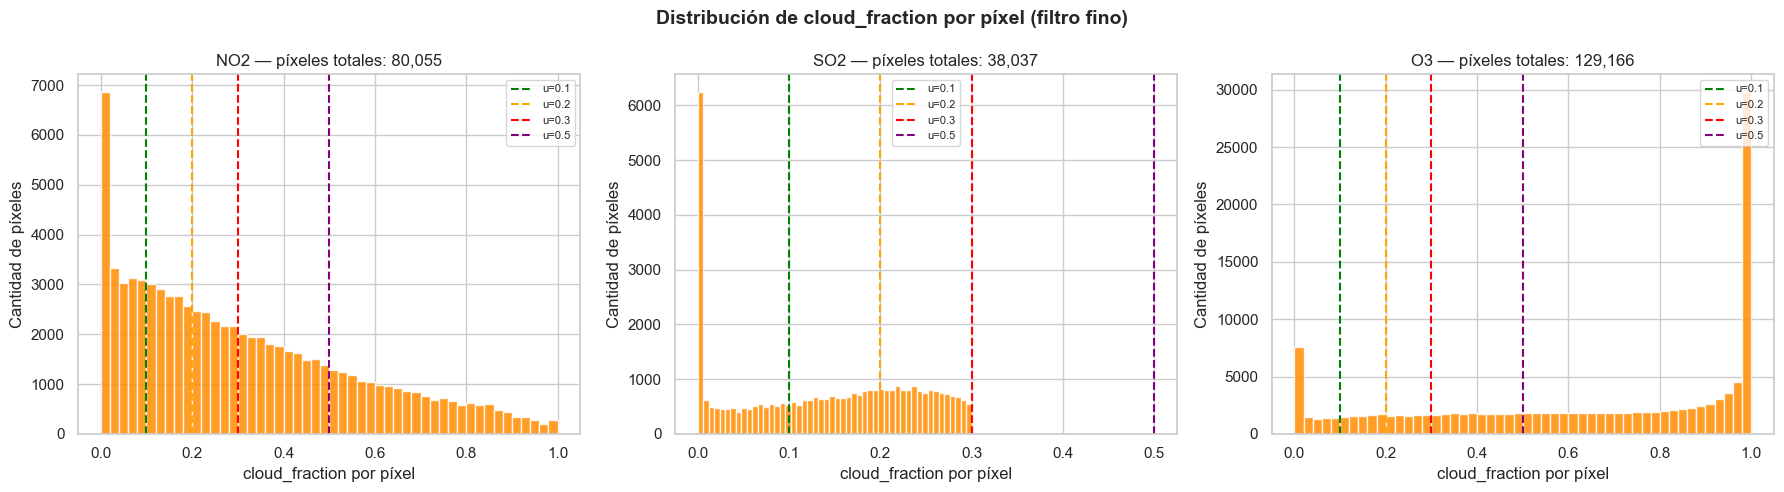


📊 Resumen filtro fino (cloud_fraction por píxel):
Dataset  Umbral  Total píxeles  Válidos  Inválidos  % Válidos
    NO2     0.1          80055    19428      60627      24.27
    NO2     0.2          80055    33461      46594      41.80
    NO2     0.3          80055    44970      35085      56.17
    NO2     0.5          80055    62087      17968      77.56
    SO2     0.1          38037    14101      23936      37.07
    SO2     0.2          38037    25390      12647      66.75
    SO2     0.3          38037    38037          0     100.00
    SO2     0.5          38037    38037          0     100.00
     O3     0.1         129166    13116     116050      10.15
     O3     0.2         129166    21066     108100      16.31
     O3     0.3         129166    29179      99987      22.59
     O3     0.5         129166    46836      82330      36.26


In [18]:
# ============================================================
# BLOQUE 2: Análisis de cloud_fraction píxel a píxel
# ============================================================

resumen_fino = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de cloud_fraction por píxel (filtro fino)', fontsize=14, fontweight='bold')

for ax, (nombre, ds) in zip(axes, datasets.items()):
    cf_pixeles = ds[f'{nombre}_cloud_fraction'].values.ravel()  # (time*lat*lon,)
    cf_pixeles = cf_pixeles[~np.isnan(cf_pixeles)]

    total_pixeles = len(cf_pixeles)
    stats = {'total_pixeles': total_pixeles}

    for u in UMBRALES:
        n_val = int(np.sum(cf_pixeles <= u))
        stats[f'validos_u{u}']     = n_val
        stats[f'invalidos_u{u}']   = total_pixeles - n_val
        stats[f'pct_validos_u{u}'] = round(n_val / total_pixeles * 100, 2)

    resumen_fino[nombre] = stats

    ax.hist(cf_pixeles, bins=50, color='darkorange', edgecolor='white', alpha=0.85)
    for u, color in zip(UMBRALES, ['green', 'orange', 'red', 'purple']):
        ax.axvline(u, color=color, linestyle='--', linewidth=1.5, label=f'u={u}')
    ax.set_title(f'{nombre} — píxeles totales: {total_pixeles:,}')
    ax.set_xlabel('cloud_fraction por píxel')
    ax.set_ylabel('Cantidad de píxeles')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Tabla resumen
rows = []
for nombre, stats in resumen_fino.items():
    for u in UMBRALES:
        rows.append({
            'Dataset':         nombre,
            'Umbral':          u,
            'Total píxeles':   stats['total_pixeles'],
            'Válidos':         stats[f'validos_u{u}'],
            'Inválidos':       stats[f'invalidos_u{u}'],
            '% Válidos':       stats[f'pct_validos_u{u}'],
        })

df_fino = pd.DataFrame(rows)
print("\n📊 Resumen filtro fino (cloud_fraction por píxel):")
print(df_fino.to_string(index=False))

## Imputación teniendo en cuenta cloud_fraction

In [19]:
# ============================================================
# BLOQUE 1: Climatología mensual por píxel (solo píxeles Buenos)
# Solo se promedian píxeles con cloud_fraction < 0.3
# Resultado: promedio histórico por (mes, lat, lon)
# ============================================================

climatologia = {}  # guardará xr.DataArray por contaminante

for nombre, ds in datasets.items():
    var_cf   = f'{nombre}_cloud_fraction'
    valores  = ds[nombre]          # (time, lat, lon)
    cf_px    = ds[var_cf]          # (time, lat, lon)

    # 1. Enmascarar: solo píxeles Buenos entran al promedio histórico
    valores_buenos = valores.where(cf_px < 0.3)

    # 2. Agrupar por mes calendario y promediar
    clim = (
        valores_buenos
        .groupby('time.month')
        .mean(dim='time')
        .compute()
    )  # shape: (12, lat, lon)

    climatologia[nombre] = clim

    # Verificación rápida
    print(f"[{nombre}] Climatología mensual construida: {clim.dims} → {clim.shape}")
    nans_por_mes = np.isnan(clim.values).sum(axis=(1, 2))
    for m, n in enumerate(nans_por_mes, start=1):
        total_px = clim.shape[1] * clim.shape[2]
        print(f"  Mes {m:02d}: {n}/{total_px} píxeles sin climatología ({n/total_px*100:.1f}%)")
    print()

[NO2] Climatología mensual construida: ('month', 'lat', 'lon') → (12, 10, 8)
  Mes 01: 2/80 píxeles sin climatología (2.5%)
  Mes 02: 2/80 píxeles sin climatología (2.5%)
  Mes 03: 2/80 píxeles sin climatología (2.5%)
  Mes 04: 0/80 píxeles sin climatología (0.0%)
  Mes 05: 2/80 píxeles sin climatología (2.5%)
  Mes 06: 0/80 píxeles sin climatología (0.0%)
  Mes 07: 0/80 píxeles sin climatología (0.0%)
  Mes 08: 0/80 píxeles sin climatología (0.0%)
  Mes 09: 0/80 píxeles sin climatología (0.0%)
  Mes 10: 0/80 píxeles sin climatología (0.0%)
  Mes 11: 2/80 píxeles sin climatología (2.5%)
  Mes 12: 4/80 píxeles sin climatología (5.0%)

[SO2] Climatología mensual construida: ('month', 'lat', 'lon') → (12, 10, 8)
  Mes 01: 0/80 píxeles sin climatología (0.0%)
  Mes 02: 1/80 píxeles sin climatología (1.2%)
  Mes 03: 0/80 píxeles sin climatología (0.0%)
  Mes 04: 0/80 píxeles sin climatología (0.0%)
  Mes 05: 1/80 píxeles sin climatología (1.2%)
  Mes 06: 0/80 píxeles sin climatología (0.0%)

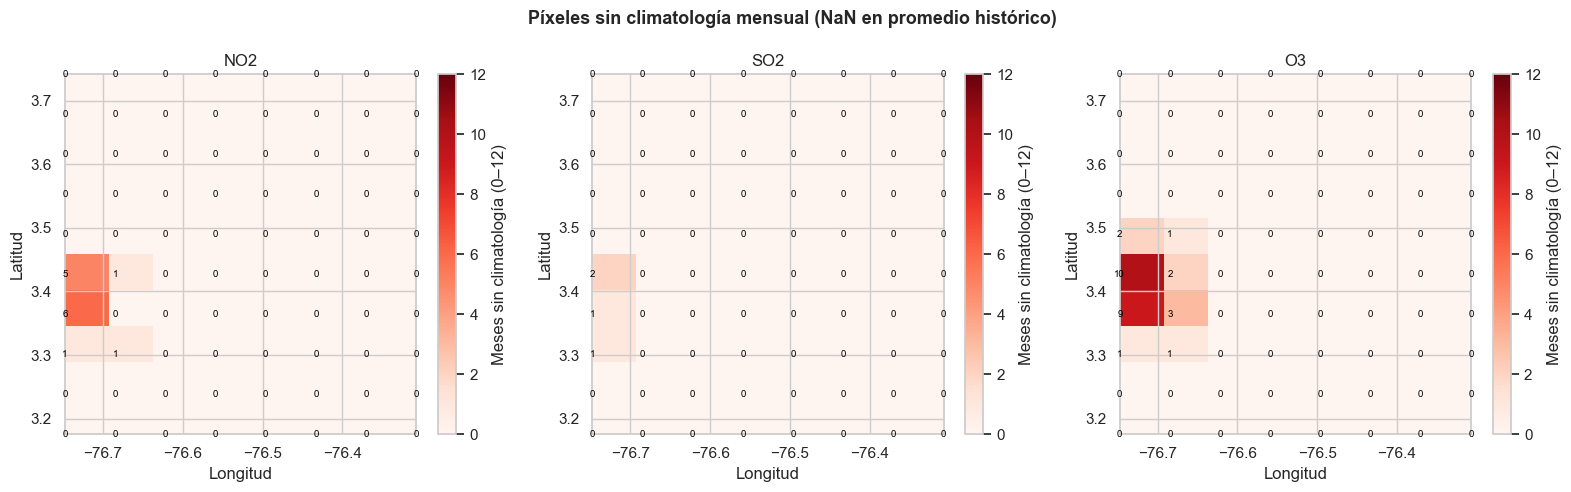

In [20]:
# ============================================================
# BLOQUE 2: ¿Hay píxeles sin climatología en algún mes?
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Píxeles sin climatología mensual (NaN en promedio histórico)', fontsize=13, fontweight='bold')

for ax, (nombre, clim) in zip(axes, climatologia.items()):
    ds    = datasets[nombre]
    lats  = ds['lat'].values
    lons  = ds['lon'].values

    # Cantidad de meses sin climatología por píxel
    meses_sin_clim = np.isnan(clim.values).sum(axis=0)  # (lat, lon)

    im = ax.imshow(
        meses_sin_clim,
        origin='upper',
        extent=[lons.min(), lons.max(), lats.min(), lats.max()],
        cmap='Reds',
        vmin=0, vmax=12,
        aspect='auto'
    )
    plt.colorbar(im, ax=ax, label='Meses sin climatología (0–12)')
    ax.set_title(f'{nombre}')
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')

    for iy, la in enumerate(lats):
        for ix, lo in enumerate(lons):
            ax.text(lo, la, str(meses_sin_clim[iy, ix]),
                    ha='center', va='center', fontsize=7, color='black')

plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# BLOQUE 3: Máscara de tres estados por píxel
# 1.0 → Píxel Bueno    (cf < 0.3)   conservar original
# 0.5 → Píxel Dudoso   (0.3–0.6)    imputar con climatología
# 0.0 → Píxel Basura   (cf >= 0.6)  invalidar, solo promedio + máscara=0
# ============================================================

mascaras = {}

for nombre, ds in datasets.items():
    cf_px = ds[f'{nombre}_cloud_fraction'].compute()  # (time, lat, lon)

    mascara = xr.full_like(cf_px, fill_value=np.nan)

    mascara = xr.where(cf_px < 0.3,                          1.0, mascara)  # Bueno
    mascara = xr.where((cf_px >= 0.3) & (cf_px < 0.6),      0.5, mascara)  # Dudoso
    mascara = xr.where(cf_px >= 0.6,                         0.0, mascara)  # Basura

    mascaras[nombre] = mascara

    # Reporte de distribución de estados
    total   = mascara.size
    buenos  = float((mascara == 1.0).sum())
    dudosos = float((mascara == 0.5).sum())
    basura  = float((mascara == 0.0).sum())

    print(f"[{nombre}] Distribución de estados:")
    print(f"  ✅ Buenos  (1.0): {buenos:>10,.0f}  ({buenos/total*100:.1f}%)")
    print(f"  ⚠️  Dudosos (0.5): {dudosos:>10,.0f}  ({dudosos/total*100:.1f}%)")
    print(f"  ❌ Basura  (0.0): {basura:>10,.0f}  ({basura/total*100:.1f}%)\n")

[NO2] Distribución de estados:
  ✅ Buenos  (1.0):     44,970  (53.9%)
  ⚠️  Dudosos (0.5):     22,920  (27.5%)
  ❌ Basura  (0.0):     12,165  (14.6%)

[SO2] Distribución de estados:
  ✅ Buenos  (1.0):     38,037  (50.6%)
  ⚠️  Dudosos (0.5):          0  (0.0%)
  ❌ Basura  (0.0):          0  (0.0%)

[O3] Distribución de estados:
  ✅ Buenos  (1.0):     29,179  (22.0%)
  ⚠️  Dudosos (0.5):     26,820  (20.2%)
  ❌ Basura  (0.0):     73,167  (55.1%)



In [22]:
# ============================================================
# BLOQUE 4 CORREGIDO: Imputación con promedio histórico mensual
# Cada contaminante se guarda en su propio Dataset independiente
# ============================================================

# Datasets individuales por contaminante
ds_no2_imputado = None
ds_so2_imputado = None
ds_o3_imputado  = None

# Mapeo contaminante → variable de destino
destinos = {
    'NO2': 'ds_no2_imputado',
    'SO2': 'ds_so2_imputado',
    'O3':  'ds_o3_imputado',
}

for nombre, ds in datasets.items():
    valores  = ds[nombre].compute()           # (time, lat, lon)
    mascara  = mascaras[nombre]               # (time, lat, lon)
    clim     = climatologia[nombre]           # (12, lat, lon) con coord 'month'

    # Expandir climatología al eje temporal completo
    meses = ds['time.month'].values           # array de enteros 1–12, shape (time,)

    clim_expandida = xr.concat(
        [clim.sel(month=m) for m in meses],
        dim='time'
    ).assign_coords(time=ds['time'])          # (time, lat, lon)

    # Construir array imputado
    valores_imputados = xr.where(
        mascara == 1.0,
        valores,           # Bueno  → original
        clim_expandida     # Dudoso → climatología | Basura → climatología
    )

    # Construir Dataset individual para este contaminante
    ds_resultado = xr.Dataset(
        {
            f'{nombre}_imputado':  valores_imputados,
            f'{nombre}_mascara':   mascara,
            f'{nombre}_original':  valores,
        },
        coords=ds.coords
    )

    # Asignar al Dataset correspondiente por nombre
    if nombre == 'NO2':
        ds_no2_imputado = ds_resultado
    elif nombre == 'SO2':
        ds_so2_imputado = ds_resultado
    elif nombre == 'O3':
        ds_o3_imputado = ds_resultado

    # Reporte
    n_imputados   = float((mascara == 0.5).sum())
    n_invalidados = float((mascara == 0.0).sum())
    print(f"[{nombre}] Imputación completada.")
    print(f"  Píxeles imputados  (dudosos):  {n_imputados:>10,.0f}")
    print(f"  Píxeles invalidados (basura):  {n_invalidados:>10,.0f}\n")

# Verificación final — confirmar que los 3 son independientes
print("=" * 50)
print("Verificación de datasets imputados:")
print(f"  ds_no2_imputado: {ds_no2_imputado}")
print(f"  ds_so2_imputado: {ds_so2_imputado}")
print(f"  ds_o3_imputado:  {ds_o3_imputado}")

[NO2] Imputación completada.
  Píxeles imputados  (dudosos):      22,920
  Píxeles invalidados (basura):      12,165

[SO2] Imputación completada.
  Píxeles imputados  (dudosos):           0
  Píxeles invalidados (basura):           0

[O3] Imputación completada.
  Píxeles imputados  (dudosos):      26,820
  Píxeles invalidados (basura):      73,167

Verificación de datasets imputados:
  ds_no2_imputado: <xarray.Dataset> Size: 1MB
Dimensions:               (time: 1042, lat: 10, lon: 8)
Coordinates:
  * time                  (time) datetime64[ns] 8kB 2020-01-01T18:09:20 ... 2...
    cf_mean               (time) float32 4kB 0.514 0.2379 0.1352 ... 0.44 0.2826
    cf_p25                (time) float32 4kB 0.1528 0.06602 ... 0.2103 0.09851
    cf_p75                (time) float32 4kB 0.8783 0.4168 ... 0.622 0.4697
    orbit_id              (time) <U19 79kB '2020-01-01_18-09-20' ... '2024-12...
    valid_pixel_fraction  (time) float32 4kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    month        

In [23]:
# ============================================================
# IMPUTACIÓN 2: Píxeles dudosos/basura por cloud_fraction
# Entrada : intermedios (sin NaN, del Bloque 1)
# Salida  : ds_no2_imputado, ds_so2_imputado, ds_o3_imputado
#           Máscara de confianza: 1.0=original | 0.5=dudoso | 0.0=basura
# ============================================================

ds_no2_imputado = None
ds_so2_imputado = None
ds_o3_imputado  = None

for nombre, ds in datasets.items():
    valores_np  = intermedios[nombre]                          # (time, lat, lon) sin NaN
    cf_px       = ds[f'{nombre}_cloud_fraction'].values        # (time, lat, lon)
    clim        = climatologia[nombre]
    meses       = ds['time.month'].values
    n_time, n_lat, n_lon = valores_np.shape

    resultado   = np.empty_like(valores_np)
    mascara_out = np.ones((n_time, n_lat, n_lon), dtype=np.float32)

    for t in range(n_time):
        imagen   = valores_np[t].copy()
        cf_slice = cf_px[t]
        clim_mes = clim.sel(month=int(meses[t])).values

        # Píxeles dudosos (0.3 ≤ CF < 0.6) → climatología, confianza 0.5
        mask_dudoso = (cf_slice >= 0.3) & (cf_slice < 0.6)
        if mask_dudoso.any():
            imagen[mask_dudoso]          = clim_mes[mask_dudoso]
            mascara_out[t][mask_dudoso]  = 0.5

        # Píxeles basura (CF ≥ 0.6) → climatología, confianza 0.0
        mask_basura = cf_slice >= 0.6
        if mask_basura.any():
            imagen[mask_basura]          = clim_mes[mask_basura]
            mascara_out[t][mask_basura]  = 0.0

        resultado[t] = imagen

    # Empaquetar con las coordenadas del ds original
    coords = {'time': ds['time'], 'lat': ds['lat'], 'lon': ds['lon']}

    ds_resultado = xr.Dataset({
        nombre:              xr.DataArray(resultado,   dims=['time', 'lat', 'lon'], coords=coords),
        f'{nombre}_mascara': xr.DataArray(mascara_out, dims=['time', 'lat', 'lon'], coords=coords),
    })

    if nombre == 'NO2':
        ds_no2_imputado = ds_resultado
    elif nombre == 'SO2':
        ds_so2_imputado = ds_resultado
    elif nombre == 'O3':
        ds_o3_imputado  = ds_resultado

    # Reporte
    px_orig    = float((mascara_out == 1.0).sum())
    px_dudosos = float((mascara_out == 0.5).sum())
    px_basura  = float((mascara_out == 0.0).sum())
    total      = mascara_out.size

    print(f"[{nombre}] ✅ Imputación por cloud_fraction completa:")
    print(f"  ✅ Originales confiables  (1.0): {px_orig:>10,.0f}  ({px_orig/total*100:.1f}%)")
    print(f"  ⚠️  Dudosos imputados      (0.5): {px_dudosos:>10,.0f}  ({px_dudosos/total*100:.1f}%)")
    print(f"  ❌ Basura imputada         (0.0): {px_basura:>10,.0f}  ({px_basura/total*100:.1f}%)\n")

# Actualizar diccionario datasets con los valores finales limpios
datasets = {
    'NO2': ds_no2_imputado,
    'SO2': ds_so2_imputado,
    'O3':  ds_o3_imputado,
}

print("✅ datasets actualizado con valores imputados. Listo para análisis final.")

[NO2] ✅ Imputación por cloud_fraction completa:
  ✅ Originales confiables  (1.0):     48,275  (57.9%)
  ⚠️  Dudosos imputados      (0.5):     22,920  (27.5%)
  ❌ Basura imputada         (0.0):     12,165  (14.6%)

[SO2] ✅ Imputación por cloud_fraction completa:
  ✅ Originales confiables  (1.0):     75,200  (100.0%)
  ⚠️  Dudosos imputados      (0.5):          0  (0.0%)
  ❌ Basura imputada         (0.0):          0  (0.0%)

[O3] ✅ Imputación por cloud_fraction completa:
  ✅ Originales confiables  (1.0):     32,893  (24.8%)
  ⚠️  Dudosos imputados      (0.5):     26,820  (20.2%)
  ❌ Basura imputada         (0.0):     73,167  (55.1%)

✅ datasets actualizado con valores imputados. Listo para análisis final.


In [24]:
print("=" * 50)
print("Verificación de datasets imputados:")
print(f"  ds_no2_imputado: {ds_no2_imputado}")
print(f"  ds_so2_imputado: {ds_so2_imputado}")
print(f"  ds_o3_imputado:  {ds_o3_imputado}")

Verificación de datasets imputados:
  ds_no2_imputado: <xarray.Dataset> Size: 675kB
Dimensions:      (time: 1042, lat: 10, lon: 8)
Coordinates:
  * time         (time) datetime64[ns] 8kB 2020-01-01T18:09:20 ... 2024-12-31...
  * lat          (lat) float64 80B 3.741 3.679 3.616 3.553 ... 3.301 3.238 3.176
  * lon          (lon) float64 64B -76.75 -76.68 -76.62 ... -76.43 -76.37 -76.31
Data variables:
    NO2          (time, lat, lon) float32 333kB 6.187e-06 ... 2.028e-05
    NO2_mascara  (time, lat, lon) float32 333kB 0.0 0.0 0.0 0.0 ... 1.0 1.0 0.5
  ds_so2_imputado: <xarray.Dataset> Size: 609kB
Dimensions:      (time: 940, lat: 10, lon: 8)
Coordinates:
  * time         (time) datetime64[ns] 8kB 2020-01-01T18:09:20 ... 2024-12-31...
  * lat          (lat) float64 80B 3.741 3.679 3.616 3.553 ... 3.301 3.238 3.176
  * lon          (lon) float64 64B -76.75 -76.68 -76.62 ... -76.43 -76.37 -76.31
Data variables:
    SO2          (time, lat, lon) float32 301kB 6.268e-05 9.625e-05 ... 0.0
   

In [25]:
# ============================================================
# BLOQUE 2: Intersección por FECHA (sin hora) y filtrado
# Los timestamps de Sentinel-5P incluyen hora de paso orbital
# por lo que se normaliza a fecha para hacer el match
# ============================================================

# Extraer fechas (sin hora) de cada ds imputado
fechas_no2 = set(pd.to_datetime(ds_no2_imputado['time'].values).normalize())
fechas_so2 = set(pd.to_datetime(ds_so2_imputado['time'].values).normalize())
fechas_o3  = set(pd.to_datetime(ds_o3_imputado['time'].values).normalize())

# Intersección de los tres
fechas_comunes = sorted(fechas_no2 & fechas_so2 & fechas_o3)

print(f"Timestamps por dataset:")
print(f"  NO2: {len(fechas_no2)}")
print(f"  SO2: {len(fechas_so2)}")
print(f"  O3:  {len(fechas_o3)}")
print(f"\nFechas en común (intersección): {len(fechas_comunes)}")
print(f"  Fechas excluidas NO2: {len(fechas_no2) - len(fechas_comunes)}")
print(f"  Fechas excluidas SO2: {len(fechas_so2) - len(fechas_comunes)}")
print(f"  Fechas excluidas O3:  {len(fechas_o3)  - len(fechas_comunes)}")

# ✅ FIX: convertir fechas_comunes a numpy datetime64 para que np.isin
# compare tipos homogéneos (datetime64[ns] vs datetime64[ns])
fechas_comunes_np = np.array(fechas_comunes, dtype='datetime64[ns]')

# Función para filtrar un ds manteniendo solo los timestamps cuya fecha esté en fechas_comunes
def filtrar_por_fechas(ds):
    fechas_ds = pd.to_datetime(ds['time'].values).normalize().values.astype('datetime64[ns]')
    mask = np.isin(fechas_ds, fechas_comunes_np)
    return ds.isel(time=mask)

ds_no2_imputado = filtrar_por_fechas(ds_no2_imputado)
ds_so2_imputado = filtrar_por_fechas(ds_so2_imputado)
ds_o3_imputado  = filtrar_por_fechas(ds_o3_imputado)

# Actualizar diccionario
datasets = {
    'NO2': ds_no2_imputado,
    'SO2': ds_so2_imputado,
    'O3':  ds_o3_imputado,
}

print(f"\n✅ Datasets sincronizados:")
for nombre, ds in datasets.items():
    print(f"  {nombre}: {ds.sizes['time']} timestamps  |  "
          f"{ds['time'].values[0]} → {ds['time'].values[-1]}")

Timestamps por dataset:
  NO2: 1042
  SO2: 940
  O3:  1661

Fechas en común (intersección): 784
  Fechas excluidas NO2: 258
  Fechas excluidas SO2: 156
  Fechas excluidas O3:  877

✅ Datasets sincronizados:
  NO2: 784 timestamps  |  2020-01-01T18:09:20.000000000 → 2024-12-31T17:31:33.000000000
  SO2: 784 timestamps  |  2020-01-01T18:09:20.000000000 → 2024-12-31T17:31:33.000000000
  O3: 784 timestamps  |  2020-01-01T18:09:20.000000000 → 2024-12-31T17:31:33.000000000


## Subida a Wasabi

In [26]:
import zarr
import tempfile
import os

BUCKET_DEST = "data-geovision-clean"

# --- 1. Consolidar en un solo Dataset ---
# Se hace merge de los tres datasets (ya sincronizados en tiempo)
# xr.merge alinea automáticamente por coordenadas comunes (time, lat, lon)
ds_consolidado = xr.merge([
    ds_no2_imputado,
    ds_so2_imputado,
    ds_o3_imputado,
], join='inner')  # 'inner' garantiza solo fechas presentes en los tres

print("✅ Dataset consolidado:")
print(ds_consolidado)
print(f"\nVariables: {list(ds_consolidado.data_vars)}")
print(f"Tamaño total: {ds_consolidado.nbytes / 1e6:.2f} MB")

✅ Dataset consolidado:
<xarray.Dataset> Size: 2MB
Dimensions:      (time: 784, lat: 10, lon: 8)
Coordinates:
  * time         (time) datetime64[ns] 6kB 2020-01-01T18:09:20 ... 2024-12-31...
  * lat          (lat) float64 80B 3.741 3.679 3.616 3.553 ... 3.301 3.238 3.176
  * lon          (lon) float64 64B -76.75 -76.68 -76.62 ... -76.43 -76.37 -76.31
Data variables:
    NO2          (time, lat, lon) float32 251kB 6.187e-06 ... 2.028e-05
    NO2_mascara  (time, lat, lon) float32 251kB 0.0 0.0 0.0 0.0 ... 1.0 1.0 0.5
    SO2          (time, lat, lon) float32 251kB 6.268e-05 9.625e-05 ... 0.0
    SO2_mascara  (time, lat, lon) float32 251kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0
    O3           (time, lat, lon) float32 251kB 0.1071 0.1081 ... 0.1158 0.113
    O3_mascara   (time, lat, lon) float32 251kB 0.0 0.0 0.0 0.0 ... 1.0 1.0 0.0

Variables: ['NO2', 'NO2_mascara', 'SO2', 'SO2_mascara', 'O3', 'O3_mascara']
Tamaño total: 1.51 MB


In [27]:
# --- 2. Exportar a Zarr local (temporal) ---
ruta_zarr_local = os.path.join(tempfile.gettempdir(), 'sentinel5p_consolidado.zarr')

# Eliminar si ya existe (evita conflictos de escritura)
if os.path.exists(ruta_zarr_local):
    import shutil
    shutil.rmtree(ruta_zarr_local)

ds_consolidado.to_zarr(ruta_zarr_local, mode='w', consolidated=True)
print(f"\n✅ Zarr guardado localmente en: {ruta_zarr_local}")

# --- 3. Subir a Wasabi ---
ruta_zarr_wasabi = f's3://{BUCKET_DEST}/GeoVision_Panel/sentinel5p_consolidado.zarr'

print(f"\nSubiendo a Wasabi: {ruta_zarr_wasabi} ...")

# Recorrer todos los archivos del zarr local y subirlos
archivos_subidos = 0
for root, dirs, files in os.walk(ruta_zarr_local):
    for archivo in files:
        ruta_local_completa = os.path.join(root, archivo)
        # Construir la ruta relativa dentro del zarr
        ruta_relativa = os.path.relpath(ruta_local_completa, ruta_zarr_local)
        ruta_s3 = f'{ruta_zarr_wasabi}/{ruta_relativa}'.replace('\\', '/')
        fs.put(ruta_local_completa, ruta_s3)
        archivos_subidos += 1

print(f"✅ Subida completa: {archivos_subidos} archivos subidos")
print(f"   Ruta en Wasabi: {ruta_zarr_wasabi}")

c:\Users\valen\Desktop\proyecto3_analitica\venv\Lib\site-packages\zarr\api\asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(



✅ Zarr guardado localmente en: C:\Users\valen\AppData\Local\Temp\sentinel5p_consolidado.zarr

Subiendo a Wasabi: s3://data-geovision-clean/GeoVision_Panel/sentinel5p_consolidado.zarr ...
✅ Subida completa: 22 archivos subidos
   Ruta en Wasabi: s3://data-geovision-clean/GeoVision_Panel/sentinel5p_consolidado.zarr


In [28]:
# --- 4. Verificación: leer de vuelta desde Wasabi ---
print("\nVerificando lectura desde Wasabi...")
ds_verificacion = xr.open_zarr(fs.get_mapper(ruta_zarr_wasabi)).compute()
print(ds_verificacion)
print(f"\n✅ Verificación exitosa — {ds_verificacion.sizes['time']} timestamps, "
      f"{len(list(ds_verificacion.data_vars))} variables")


Verificando lectura desde Wasabi...
<xarray.Dataset> Size: 2MB
Dimensions:      (time: 784, lat: 10, lon: 8)
Coordinates:
  * time         (time) datetime64[ns] 6kB 2020-01-01T18:09:20 ... 2024-12-31...
  * lat          (lat) float64 80B 3.741 3.679 3.616 3.553 ... 3.301 3.238 3.176
  * lon          (lon) float64 64B -76.75 -76.68 -76.62 ... -76.43 -76.37 -76.31
Data variables:
    NO2          (time, lat, lon) float32 251kB 6.187e-06 ... 2.028e-05
    NO2_mascara  (time, lat, lon) float32 251kB 0.0 0.0 0.0 0.0 ... 1.0 1.0 0.5
    O3           (time, lat, lon) float32 251kB 0.1071 0.1081 ... 0.1158 0.113
    O3_mascara   (time, lat, lon) float32 251kB 0.0 0.0 0.0 0.0 ... 1.0 1.0 0.0
    SO2          (time, lat, lon) float32 251kB 6.268e-05 9.625e-05 ... 0.0
    SO2_mascara  (time, lat, lon) float32 251kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0

✅ Verificación exitosa — 784 timestamps, 6 variables
